<a href="https://colab.research.google.com/github/arago07/Egocentric-Hand-Occlusion-Segmentation/blob/main/Egocentric_Hand_Segmentation_DeepLabV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
from google.colab import drive

# 1. 구글 드라이브 마운트 (권한 허용 팝업 클릭)
drive.mount('/content/drive')

# 2. 작업할 폴더로 이동
%cd /content/drive/MyDrive/egocentric

print("구글 드라이브 연결 및 경로 설정 완료!")

Mounted at /content/drive
/content/drive/MyDrive/egocentric
구글 드라이브 연결 및 경로 설정 완료!


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch import ToTensorV2

class EgocentricDataset(Dataset):
  def __init__(self, root, json_file, transform=None):
    self.root = root
    self.coco = COCO(json_file)
    self.ids = list(self.coco.imgs.keys())
    self.transform = transform

  def __getitem__(self, index):
    # 1. image 불러오기
    img_id = self.ids[index]
    img_metadata = self.coco.loadImgs(img_id)[0]
    path = img_metadata['file_name']
    img = cv2.imread(os.path.join(self.root, path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. mask(정답) 생성
    ann_ids = self.coco.getAnnIds(imgIds=img_id)
    anns = self.coco.loadAnns(ann_ids)
    mask = np.zeros((img_metadata['height'], img_metadata['width'])) # mask를 검은색으로

    for ann in anns:
      # hand=1, bottle=2, cup=3
      mask = np.maximum(mask, self.coco.annToMask(ann) * ann['category_id']) # 겹치는 경우 대비 max 사용

    # 3. data 증강
    if self.transform:
      augmented = self.transform(image=img, mask=mask) # image, mask 동시에 augmentation
      img = augmented['image']
      mask = augmented['mask']

    return img, mask.long() # datatype: -> 'int64'

  def __len__(self):
    return len(self.ids)

# defining augmentation rule - training
train_transform = A.Compose([
    A.Resize(512, 512), # 모델 입력을 위해 크기 통일
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.5), # light changes
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# dataset 객체 생성
dataset = EgocentricDataset(root='dataset/images',
                             json_file='dataset/annotations/instances_default.json',
                             transform=train_transform)

print(f"총 {len(dataset)}개의 데이터가 준비되었습니다.")



loading annotations into memory...
Done (t=0.64s)
creating index...
index created!
총 60개의 데이터가 준비되었습니다.


The form of images: torch.Size([4, 3, 512, 512])
The form of masks: torch.Size([4, 512, 512])


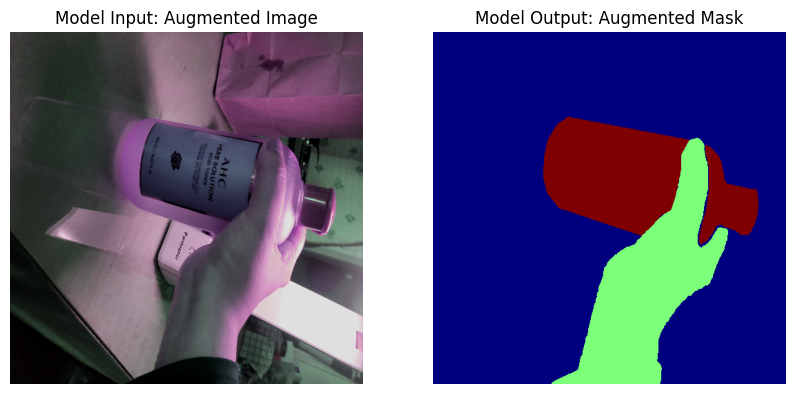

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# 1. DataLoader
train_loader = DataLoader(dataset, batch_size=4, shuffle=True) # to prevent memorizing answers

# 2. receiving data from dataloader using batch
images, masks = next(iter(train_loader))

print(f"The form of images: {images.shape}")
print(f"The form of masks: {masks.shape}")

# 3. check data before put in the model
img = images[0].numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

mask = masks[0].numpy()

# drawing
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Model Input: Augmented Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Model Output: Augmented Mask")
plt.imshow(mask, cmap='jet') # class number에 따라 다른 색상
plt.axis('off')

plt.show()

In [5]:
import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import torch.nn as nn

# 1. DeepLabV3
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)

# 2. modifying output layer
num_classes = 4 # 3 classes + 1 background

# 3. remove classifier, add new one
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1), stride=(1,1))

print(f"The number of output class: {num_classes}")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 180MB/s]


The number of output class: 4


In [9]:
import torch
import torch.optim as optim

# turn on the GPU in google colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"사용중인 엔진: {device}")

# setting loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # use 'Adam'

# setting epoch
num_epochs = 5

print("Started to train the model")

for epoch in range(num_epochs):
  model.train()
  epoch_loss = 0

  for images, masks in train_loader:
    images = images.to(device)
    masks = masks.to(device)

    # prediction - grading - updating gradient
    optimizer.zero_grad()
    outputs = model(images)['out'] # answers만
    loss = criterion(outputs, masks)
    loss.backward() # calculate new gradient
    optimizer.step() # update gradient

    epoch_loss += loss.item()

  avg_loss = epoch_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

print("Finished training the model")

"""
Result
-------------------------------
사용중인 엔진: cuda
Started to train the model
Epoch [1/5] | Loss: 0.7925
Epoch [2/5] | Loss: 0.6329
Epoch [3/5] | Loss: 0.5776
Epoch [4/5] | Loss: 0.5612
Epoch [5/5] | Loss: 0.5181
Finished training the model
"""

사용중인 엔진: cuda
Started to train the model
Epoch [1/5] | Loss: 0.7925
Epoch [2/5] | Loss: 0.6329
Epoch [3/5] | Loss: 0.5776
Epoch [4/5] | Loss: 0.5612
Epoch [5/5] | Loss: 0.5181
Finished training the model


In [10]:
import torch

# 1. 저장 위치 지정
save_path = '/content/drive/MyDrive/egocentric/my_deeplabv3_model.pth'

torch.save(model.state_dict(), save_path)

print(f"Finished Saving the File.")
print(f"저장 위치: {save_path}")

Finished Saving the File.
저장 위치: /content/drive/MyDrive/egocentric/my_deeplabv3_model.pth
